<a href="https://colab.research.google.com/github/iddadobroc/DSML_Group11_Clustering/blob/main/DSML_Group11LA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reach for Change

Part 1: Uncovering Donor Profiles Through Clustering
Data Science and Machine Learning Group Project 2025/2026

| Student #    | Name |
| :-------- | :------- |
| aaa  | 111    |
| bbb |   222   |
| ccc    | 333    |
| 20251105 | Kehinde Adewusi |


In [ ]:
import pandas as pd


In [ ]:

df = pd.read_csv('https://raw.githubusercontent.com/iddadobroc/DSML_Group11_Clustering/refs/heads/main/donors_descriptive.csv')
df.head()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13560 entries, 0 to 13559
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CONTROL_NUMBER               13560 non-null  int64  
 1   CARD_PROM_12                 13297 non-null  float64
 2   CHILDREN                     13289 non-null  float64
 3   DONOR_AGE                    9970 non-null   float64
 4   DONOR_GENDER                 13303 non-null  object 
 5   FILE_CARD_GIFT               13292 non-null  float64
 6   FREQUENCY_STATUS_97NK        13296 non-null  float64
 7   HOME_OWNER                   13292 non-null  object 
 8   INCOME_GROUP                 10273 non-null  float64
 9   LAST_GIFT_AMT                13296 non-null  float64
 10  LIFETIME_CARD_PROM           13289 non-null  float64
 11  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 12  LIFETIME_GIFT_COUNT          13304 non-null  float64
 13  LIFETIME_MAX_GIF

In [ ]:
df.shape

(13560, 40)

In [ ]:
df.isna().sum()

,0
CONTROL_NUMBER,0
CARD_PROM_12,263
CHILDREN,271
DONOR_AGE,3590
DONOR_GENDER,257
FILE_CARD_GIFT,268
FREQUENCY_STATUS_97NK,264
HOME_OWNER,268
INCOME_GROUP,3287
LAST_GIFT_AMT,264


In [ ]:
df

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


In [ ]:
df1=df.copy()

In [ ]:
df2=df.copy()
df2.drop(columns=["WEALTH_RATING"], inplace = True)

In [ ]:
df1

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


In [ ]:
df2['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

In [ ]:
df1.set_index("CONTROL_NUMBER", inplace = True)

In [ ]:
df1

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,32.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,33.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,12.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN


SES Values 1 to 5 demographic profiles

In [ ]:
df2 = df1.copy()
# check uniques SES before cleaning
print('SES - unique values:', df2['SES'].unique())
print('SES - total "?":', (df2['SES'] == '?').sum())
print('SES - missing (NaN):', df2['SES'].isna().sum())

SES - unique values: ['2' '3' '1' '4' nan '?']
SES - total "?": 292
SES - missing (NaN): 286


Sub "?" for NaN

In [ ]:
import numpy as np
df2['SES'] = df2['SES'].replace('?', np.nan)
print('SES - unique values:', df2['SES'].unique())
print('SES - missing (NaN):', df2['SES'].isna().sum())

SES - unique values: ['2' '3' '1' '4' nan]
SES - missing (NaN): 578


URBANICITY - values '?'


In [ ]:
print('URBANICITY - unique values:', df2['URBANICITY'].unique())
print('URBANICITY - total "?":', (df2['URBANICITY'] == '?').sum())
print('URBANICITY - missing (NaN):', df2['URBANICITY'].isna().sum())

URBANICITY - unique values: ['T' 'R' 'U' 'C' 'S' nan '?']
URBANICITY - total "?": 295
URBANICITY - missing (NaN): 278


Sub "?" for NaN, same as SES


In [ ]:
df2['URBANICITY'] = df2['URBANICITY'].replace('?', np.nan)

print('URBANICITY - unique values:', df2['URBANICITY'].unique())
print('URBANICITY - missing (NaN):', df2['URBANICITY'].isna().sum())

URBANICITY - unique values: ['T' 'R' 'U' 'C' 'S' nan]
URBANICITY - missing (NaN): 573


HOME_OWNER 'U' (Unknown) -> NaN

In [ ]:
print('HOME_OWNER unique before:', df2['HOME_OWNER'].unique())
df2['HOME_OWNER'] = df2['HOME_OWNER'].replace('U', np.nan)
print('HOME_OWNER unique after:', df2['HOME_OWNER'].unique())

HOME_OWNER unique before: ['H' 'U' nan]
HOME_OWNER unique after: ['H' nan]


Clamp PEP_STAR to valid binary [0, 1], still to be solved properly remove floats, round isn't working

In [ ]:
df2['PEP_STAR'].unique()

array([ 0.        ,  1.        , -0.5298607 ,         nan,  2.00360856])

In [ ]:
print('\nPEP_STAR unique before:', sorted(df2['PEP_STAR'].dropna().unique()))
df2['PEP_STAR'] = df2['PEP_STAR'].clip(0, 1).round(0)
print('PEP_STAR unique after:', sorted(df2['PEP_STAR'].dropna().unique()))



PEP_STAR unique before: [np.float64(-0.5298607009385796), np.float64(0.0), np.float64(1.0), np.float64(2.0036085611535746)]
PEP_STAR unique after: [np.float64(0.0), np.float64(1.0)]


Clamp RECENT_STAR_STATUS to valid binary [0, 1]

In [ ]:
print('\nRECENT_STAR_STATUS range before: [{:.2f}, {:.2f}]'.format(
    df2['RECENT_STAR_STATUS'].min(), df2['RECENT_STAR_STATUS'].max()))
df2['RECENT_STAR_STATUS'] = df2['RECENT_STAR_STATUS'].clip(0, 1).round()
print('RECENT_STAR_STATUS unique after:', sorted(df2['RECENT_STAR_STATUS'].dropna().unique()))



RECENT_STAR_STATUS range before: [-7.81, 22.00]
RECENT_STAR_STATUS unique after: [np.float64(0.0), np.float64(1.0)]


recent star status maybe still to be refined


In [ ]:
df2['RECENT_STAR_STATUS'].unique()

array([ 0.,  1., nan])

Clamp INCOME_GROUP to valid range [1, 7]


In [ ]:
df2['INCOME_GROUP'].unique()

array([ 5.        ,         nan,  4.        ,  6.        ,  3.        ,
        2.        ,  9.49079901,  1.        ,  7.        , -1.72899876])

In [ ]:
print('\nINCOME_GROUP range before: [{:.2f}, {:.2f}]'.format(
    df2['INCOME_GROUP'].min(), df2['INCOME_GROUP'].max()))
df2['INCOME_GROUP'] = df2['INCOME_GROUP'].clip(1, 7).round()
print('INCOME_GROUP unique after:', sorted(df2['INCOME_GROUP'].dropna().unique()))



INCOME_GROUP range before: [-1.73, 9.49]
INCOME_GROUP unique after: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]


Detect all numeric columns that currently have negative values

In [ ]:
num_cols_all = df2.select_dtypes(include='number').columns
cols_with_negatives = np.array([c for c in num_cols_all if (df2[c] < 0).sum() > 0])


In [ ]:
print('Colunas com valores negativos:')
print(cols_with_negatives)
print()
for c in cols_with_negatives:
    print(f'  {c}: {(df2[c] < 0).sum()} negatives  (min={df2[c].min():.3f})')

Colunas com valores negativos:
['CHILDREN' 'FILE_CARD_GIFT' 'FREQUENCY_STATUS_97NK' 'LAST_GIFT_AMT'
 'LIFETIME_CARD_PROM' 'LIFETIME_GIFT_AMOUNT' 'LIFETIME_GIFT_COUNT'
 'LIFETIME_MAX_GIFT_AMT' 'LIFETIME_MIN_GIFT_AMT' 'LIFETIME_PROM'
 'MEDIAN_HOME_VALUE' 'MEDIAN_HOUSEHOLD_INCOME' 'MONTHS_SINCE_FIRST_GIFT'
 'MONTHS_SINCE_LAST_PROM_RESP' 'NUMBER_PROM_12' 'PCT_ATTRIBUTE1'
 'PCT_ATTRIBUTE2' 'PCT_ATTRIBUTE3' 'PCT_ATTRIBUTE4' 'PER_CAPITA_INCOME'
 'RECENT_AVG_CARD_GIFT_AMT' 'RECENT_AVG_GIFT_AMT'
 'RECENT_CARD_RESPONSE_COUNT' 'RECENT_CARD_RESPONSE_PROP'
 'RECENT_RESPONSE_COUNT' 'RECENT_RESPONSE_PROP' 'WEALTH_RATING']

  CHILDREN: 75 negatives  (min=-2.341)
  FILE_CARD_GIFT: 64 negatives  (min=-10.100)
  FREQUENCY_STATUS_97NK: 70 negatives  (min=-1.365)
  LAST_GIFT_AMT: 70 negatives  (min=-21.719)
  LIFETIME_CARD_PROM: 68 negatives  (min=-7.189)
  LIFETIME_GIFT_AMOUNT: 66 negatives  (min=-245.473)
  LIFETIME_GIFT_COUNT: 70 negatives  (min=-18.583)
  LIFETIME_MAX_GIFT_AMT: 67 negatives  (min=-33.4

Clip to 0 on columns that cannot be negative

In [ ]:
non_negative_cols = [
    'CHILDREN', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK',
    'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
    'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
    'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
    'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
    'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PER_CAPITA_INCOME',
    'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT',
    'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP',
    'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'MONTHS_SINCE_LAST_GIFT',
    'CARD_PROM_12'
]

for col in non_negative_cols:
    if col in df2.columns:
        df2[col] = df2[col].clip(lower=0)

# Verify no negatives remain
remaining = {c: (df2[c] < 0).sum() for c in df2.select_dtypes(include='number').columns if (df2[c] < 0).sum() > 0}
print('Negatives :', remaining if remaining else "")

Negatives : {'WEALTH_RATING': np.int64(67)}



Missing values??

In [ ]:
missing = df2.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing.to_string())


Columns with missing values:
HOME_OWNER                     6309
WEALTH_RATING                  6269
DONOR_AGE                      3590
INCOME_GROUP                   3287
SES                             578
URBANICITY                      573
MONTHS_SINCE_LAST_PROM_RESP     430
PCT_ATTRIBUTE3                  282
MONTHS_SINCE_FIRST_GIFT         278
RECENT_CARD_RESPONSE_COUNT      278
PCT_ATTRIBUTE1                  276
LIFETIME_MAX_GIFT_AMT           276
RECENT_STAR_STATUS              275
MONTHS_SINCE_LAST_GIFT          275
LIFETIME_PROM                   274
RECENT_CARD_RESPONSE_PROP       274
NUMBER_PROM_12                  272
LIFETIME_GIFT_AMOUNT            272
LIFETIME_CARD_PROM              271
CHILDREN                        271
RECENT_AVG_GIFT_AMT             268
FILE_CARD_GIFT                  268
PCT_ATTRIBUTE4                  267
RECENT_RESPONSE_COUNT           266
RECENCY_STATUS_96NK             266
PEP_STAR                        265
FREQUENCY_STATUS_97NK           264

Columns DONOR_GENDER, HOME_OWNER, RECENCY_STATUS_96NK, SES, URBANICITY.
We impute with the mode (most frequent value) for each.

In [ ]:
cat_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']
for col in cat_cols:
    n_miss = df2[col].isna().sum()
    mode_val = df2[col].mode()[0]
    print(f'{col}: {n_miss} missing | mode = {mode_val!r}')
    print(f'  {dict(df2[col].value_counts(dropna=False))}')
    print()

DONOR_GENDER: 257 missing | mode = 'F'
  {'F': np.int64(7222), 'M': np.int64(5376), 'U': np.int64(705), nan: np.int64(257)}

HOME_OWNER: 6309 missing | mode = 'H'
  {'H': np.int64(7251), nan: np.int64(6309)}

RECENCY_STATUS_96NK: 266 missing | mode = 'A'
  {'A': np.int64(8202), 'S': np.int64(2877), 'F': np.int64(1048), 'N': np.int64(825), 'E': np.int64(283), nan: np.int64(266), 'L': np.int64(59)}

SES: 578 missing | mode = '2'
  {'2': np.int64(6365), '1': np.int64(4091), '3': np.int64(2277), nan: np.int64(578), '4': np.int64(249)}

URBANICITY: 573 missing | mode = 'S'
  {'S': np.int64(3103), 'C': np.int64(2741), 'T': np.int64(2734), 'R': np.int64(2732), 'U': np.int64(1677), nan: np.int64(573)}



In [ ]:
cat_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']
for col in cat_cols:
    mode_val = df2[col].mode()[0]
    df2[col] = df2[col].fillna(mode_val)

print('Missing in categorical columns')
print(df2[cat_cols].isna().sum())

Missing in categorical columns
DONOR_GENDER           0
HOME_OWNER             0
RECENCY_STATUS_96NK    0
SES                    0
URBANICITY             0
dtype: int64


2.4.3 CHILDREN (median + round + clamp [0, 6])

CHILDREN is a count — it must be a non-negative integer. We impute with the median, then round and clamp to [0, 6].

In [ ]:
col = 'CHILDREN'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()}')
print(f'\nValue counts:')
print(df2[col].value_counts(dropna=False).sort_index())

CHILDREN: 271 missing (2.0%)
Median: 2.0

Value counts:
CHILDREN
0.000000    2656
1.000000    2658
2.000000    2631
3.000000    2630
4.000000    2646
6.264709      68
NaN          271
Name: count, dtype: int64


In [ ]:
df2['CHILDREN'] = df2['CHILDREN'].fillna(df2['CHILDREN'].median()).round().clip(0, 6)
print('CHILDREN after imputation:')
print(df2['CHILDREN'].value_counts(dropna=False).sort_index())
print(f'Missing: {df2["CHILDREN"].isna().sum()}')

CHILDREN after imputation:
CHILDREN
0.0    2656
1.0    2658
2.0    2902
3.0    2630
4.0    2646
6.0      68
Name: count, dtype: int64
Missing: 0


DONOR_AGE

In [ ]:
col = 'DONOR_AGE'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()} | Mean: {df2[col].mean():.1f}')
print(f'Min: {df2[col].min()} | Max: {df2[col].max()}')

DONOR_AGE: 3590 missing (26.5%)
Median: 60.0 | Mean: 58.9
Min: 0.0 | Max: 108.93426092026507


(median — 26.5% missing)-Age distribution is typically right skewed. Maybe use median

In [ ]:
df2['DONOR_AGE'] = df2['DONOR_AGE'].fillna(df2['DONOR_AGE'].median())
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')

DONOR_AGE: 0 missing (0.0%)


Income Group

In [ ]:
col = 'INCOME_GROUP'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()}')
print(f'\nValue counts (incl. NaN):')
print(df2[col].value_counts(dropna=False).sort_index())

INCOME_GROUP: 3287 missing (24.2%)
Median: 4.0

Value counts (incl. NaN):
INCOME_GROUP
1.0    1278
2.0    1758
3.0    1133
4.0    1732
5.0    2177
6.0    1076
7.0    1119
NaN    3287
Name: count, dtype: int64


INCOME_GROUP (median — 24.2% missing)
INCOME_GROUP is an ordinal [1–7]. We impute with the median and round to keep valid integer categories.

In [ ]:
df2['INCOME_GROUP'] = df2['INCOME_GROUP'].fillna(df2['INCOME_GROUP'].median()).round().clip(1, 7)
print(df2[col].value_counts(dropna=False).sort_index())


INCOME_GROUP
1.0    1278
2.0    1758
3.0    1133
4.0    5019
5.0    2177
6.0    1076
7.0    1119
Name: count, dtype: int64


Check Whats missing
We still have to check for:
  Duplicates on both columns and after pearsons remove the dependant var

In [ ]:
print('Duplicated index (CONTROL_NUMBER):', df2.index.duplicated().sum())
print('Duplicated rows (all columns):', df2.duplicated().sum())

Duplicated index (CONTROL_NUMBER): 0
Duplicated rows (all columns): 0


In [ ]:
df2 = df2[~df2.index.duplicated(keep='first')]
df2 = df2.drop_duplicates()
print('Shape after duplicate removal:', df2.shape)

Shape after duplicate removal: (13560, 39)


Pearsons Diagram to check on Dependancy

Dataset usado para Pearson: df2
Nº de variáveis no diagrama: 34


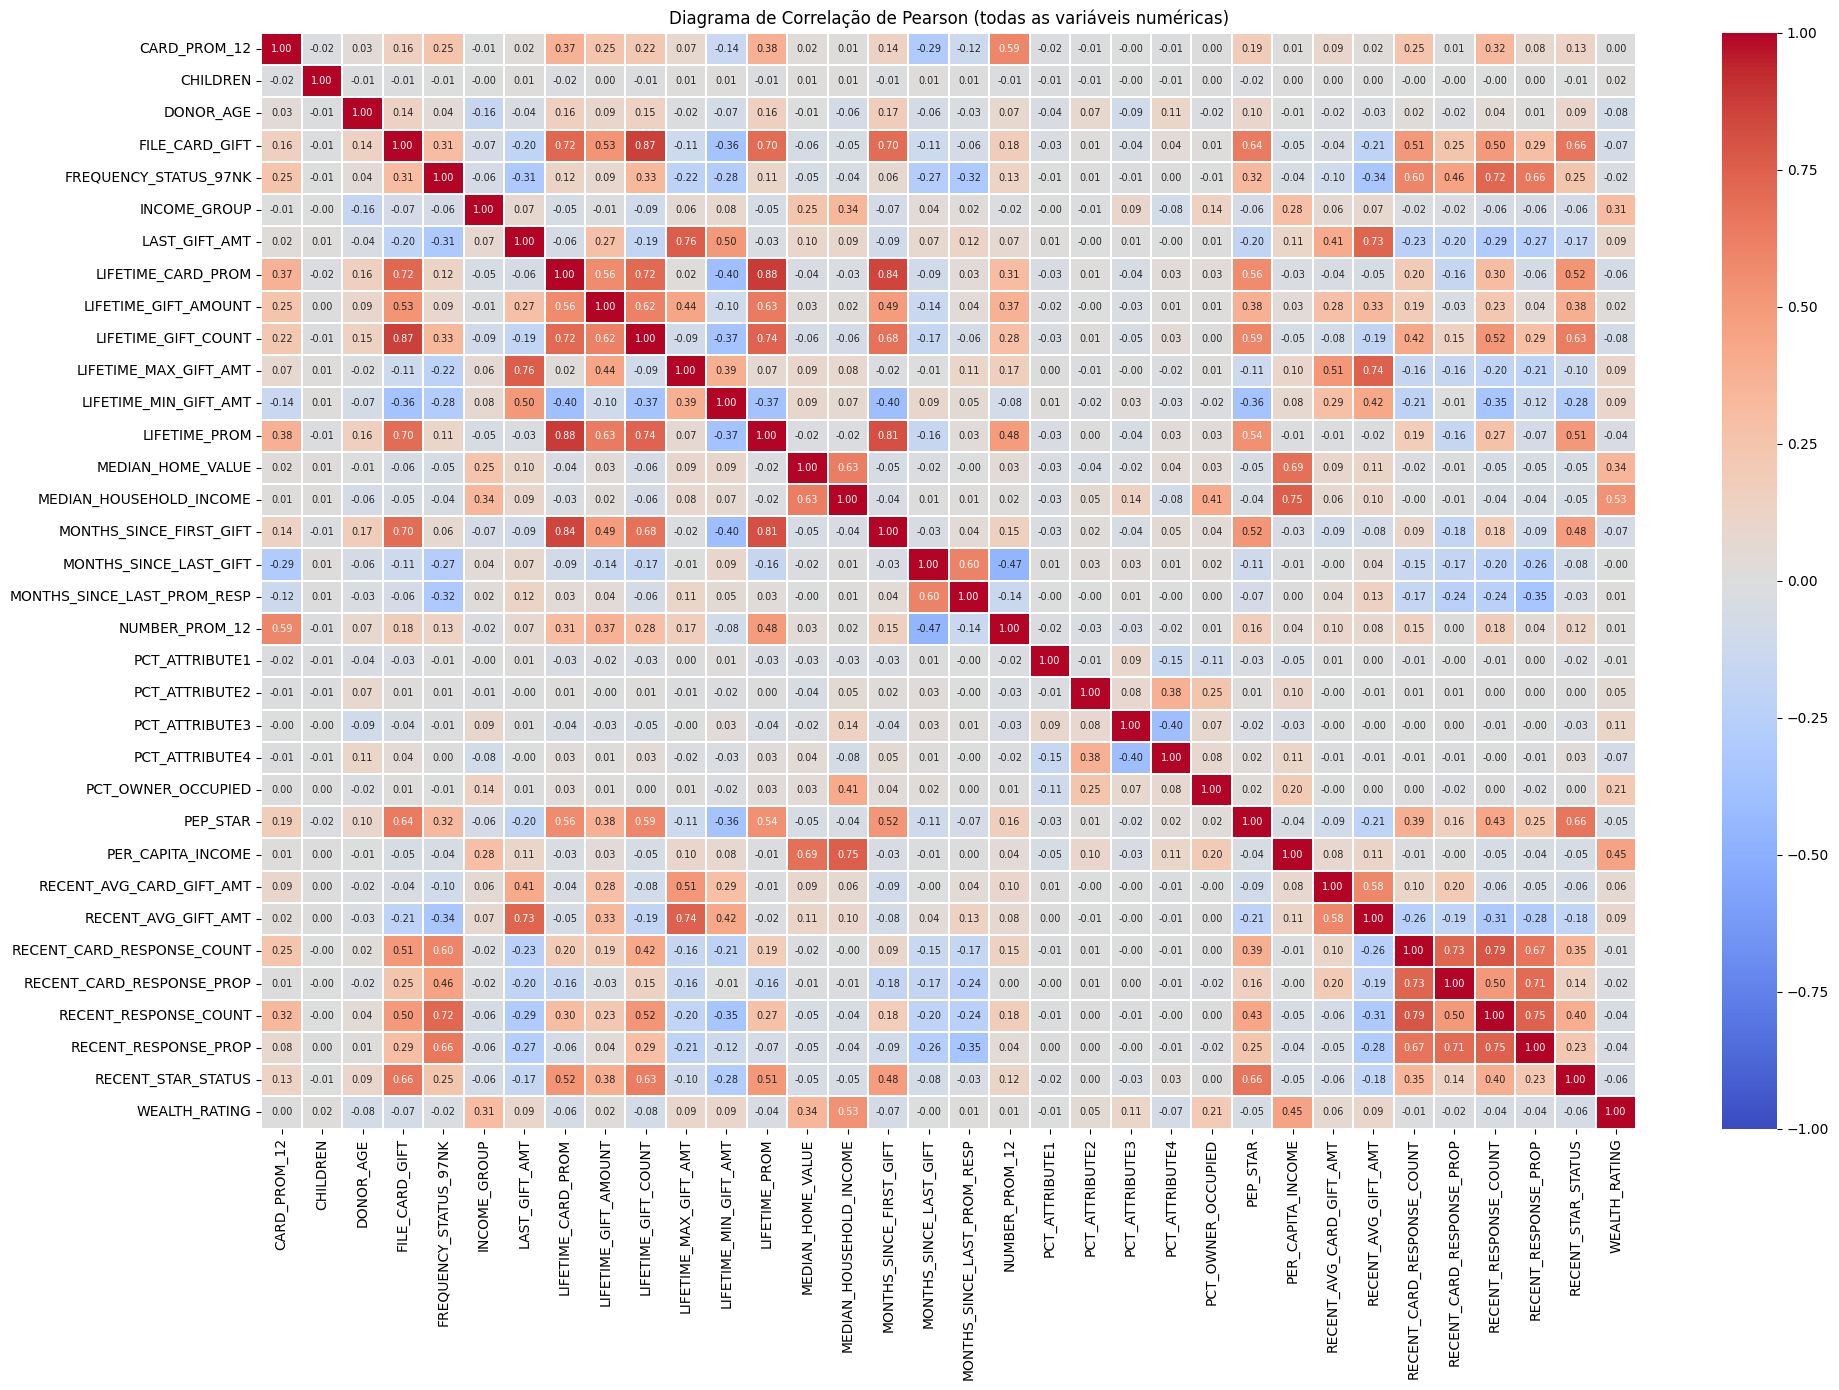

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# usar o dataset mais avançado que existir
if 'df5' in globals():
    df_corr_base = df5.copy()
elif 'df4' in globals():
    df_corr_base = df4.copy()
else:
    df_corr_base = df2.copy()

# Pearson só funciona em colunas numéricas
corr_df = df_corr_base.select_dtypes(include='number')
pearson_corr = corr_df.corr(method='pearson')

print('Dataset usado para Pearson:', 'df5' if 'df5' in globals() else ('df4' if 'df4' in globals() else 'df2'))
print('Nº de variáveis no diagrama:', pearson_corr.shape[0])

plt.figure(figsize=(20, 14))
sns.heatmap(
    pearson_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=False,
    linewidths=0.2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
    )
plt.title('Diagrama de Correlação de Pearson (todas as variáveis numéricas)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

thr = 0.75

if 'pearson_corr' not in globals():
    corr_df = df5.select_dtypes(include='number') if 'df5' in globals() else df2.select_dtypes(include='number')
    pearson_corr = corr_df.corr(method='pearson')

corr_abs = pearson_corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_r'})
)
pairs = pairs[pairs['abs_r'] > thr].sort_values('abs_r', ascending=False).reset_index(drop=True)

# adicionar r com sinal para análise
pairs['r'] = pairs.apply(lambda x: pearson_corr.loc[x['var1'], x['var2']], axis=1)
pairs = pairs[['var1', 'var2', 'r', 'abs_r']]

print(f'Pares com |r| > {thr}: {len(pairs)}')
display(pairs)

# sugestao automatica simples: remover var2 de cada par
if len(pairs) > 0:
    suggested_remove = pairs['var2'].drop_duplicates().tolist()
    print('\nSugestao (automatica): remover uma por par, começando por estas:')
    print(suggested_remove)

Pares com |r| > 0.75: 7


,var1,var2,r,abs_r
0,LIFETIME_CARD_PROM,LIFETIME_PROM,0.880728,0.880728
1,FILE_CARD_GIFT,LIFETIME_GIFT_COUNT,0.866220,0.866220
2,LIFETIME_CARD_PROM,MONTHS_SINCE_FIRST_GIFT,0.843808,0.843808
3,LIFETIME_PROM,MONTHS_SINCE_FIRST_GIFT,0.806433,0.806433
4,RECENT_CARD_RESPONSE_COUNT,RECENT_RESPONSE_COUNT,0.788052,0.788052
5,LAST_GIFT_AMT,LIFETIME_MAX_GIFT_AMT,0.758006,0.758006
6,MEDIAN_HOUSEHOLD_INCOME,PER_CAPITA_INCOME,0.753560,0.753560



Sugestao (automatica): remover uma por par, começando por estas:
['LIFETIME_PROM', 'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_RESPONSE_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'PER_CAPITA_INCOME']


Drop correlated features (|r| > 0.75) — keep the more informative variable in each pair

- LIFETIME_PROM (r=0.88 with LIFETIME_CARD_PROM) → drop LIFETIME_PROM, keep LIFETIME_CARD_PROM
- LIFETIME_GIFT_COUNT (r=0.87 with FILE_CARD_GIFT) → drop LIFETIME_GIFT_COUNT, keep FILE_CARD_GIFT
- MONTHS_SINCE_FIRST_GIFT (r=0.84 with LIFETIME_CARD_PROM) → drop MONTHS_SINCE_FIRST_GIFT
- RECENT_CARD_RESPONSE_COUNT (r=0.79 with RECENT_RESPONSE_COUNT) → drop card count, keep total count
- LIFETIME_MAX_GIFT_AMT (r=0.76 with LAST_GIFT_AMT) → drop lifetime max, keep recency signal
- MEDIAN_HOUSEHOLD_INCOME (r=0.75 with PER_CAPITA_INCOME) → drop median household, keep per capita

Also drop WEALTH_RATING — pre-computed external score, not meaningful for unsupervised profiling.


Dropped: ['LIFETIME_PROM', 'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_CARD_RESPONSE_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'MEDIAN_HOUSEHOLD_INCOME', 'WEALTH_RATING']
Shape before: (13560, 39)
Shape after:  (13560, 32)


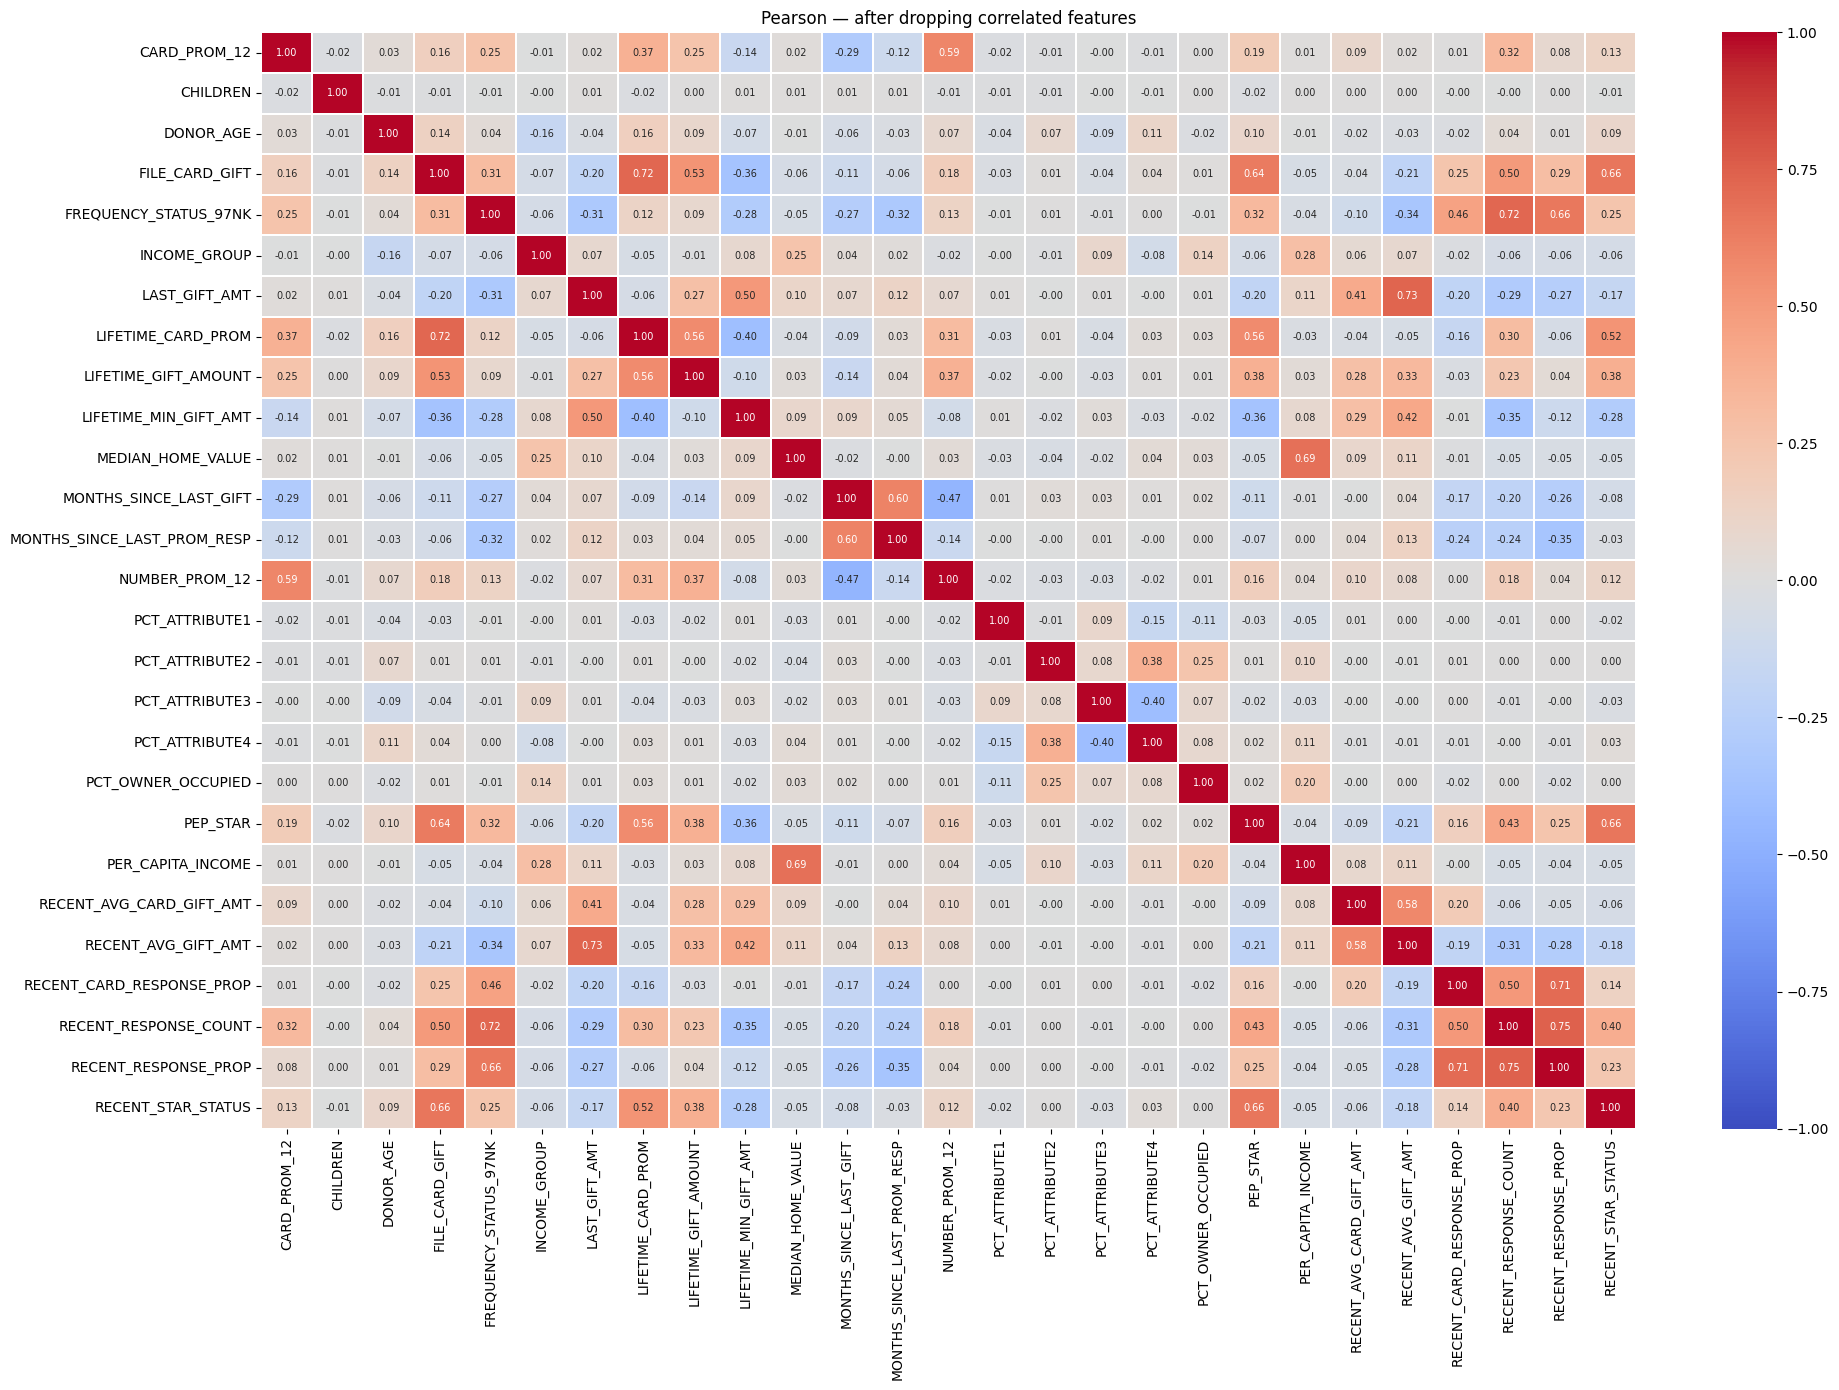

In [ ]:
drop_cols = [
    'LIFETIME_PROM',            # r=0.88 with LIFETIME_CARD_PROM
    'LIFETIME_GIFT_COUNT',      # r=0.87 with FILE_CARD_GIFT
    'MONTHS_SINCE_FIRST_GIFT',  # r=0.84 with LIFETIME_CARD_PROM
    'RECENT_CARD_RESPONSE_COUNT', # r=0.79 with RECENT_RESPONSE_COUNT
    'LIFETIME_MAX_GIFT_AMT',    # r=0.76 with LAST_GIFT_AMT
    'MEDIAN_HOUSEHOLD_INCOME',  # r=0.75 with PER_CAPITA_INCOME
    'WEALTH_RATING',            # pre-computed external score
]

df_clean = df2.drop(columns=drop_cols, errors='ignore')

print(f'Dropped: {[c for c in drop_cols if c in df2.columns]}')
print(f'Shape before: {df2.shape}')
print(f'Shape after:  {df_clean.shape}')

# Updated Pearson after feature reduction
corr_clean = df_clean.select_dtypes(include='number').corr(method='pearson')

plt.figure(figsize=(20, 14))
sns.heatmap(
    corr_clean,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
)
plt.title('Pearson — after dropping correlated features')
plt.tight_layout()
plt.show()


Final check after feature reduction

In [ ]:
print('Shape:', df_clean.shape)
print('Missing values:', df_clean.isna().sum().sum())
print('\nDtypes:')
print(df_clean.dtypes.value_counts())
print('\nObject columns still to encode:')
print(df_clean.select_dtypes(include='object').columns.tolist())


Shape: (13560, 32)
Missing values: 6547

Dtypes:
float64    27
object      5
Name: count, dtype: int64

Object columns still to encode:
['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']


In [ ]:
miss_detail = df_clean.isna().sum()
miss_detail = miss_detail[miss_detail > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(miss_detail.to_string())

Columns with missing values:
MONTHS_SINCE_LAST_PROM_RESP    430
PCT_ATTRIBUTE3                 282
PCT_ATTRIBUTE1                 276
MONTHS_SINCE_LAST_GIFT         275
RECENT_STAR_STATUS             275
RECENT_CARD_RESPONSE_PROP      274
LIFETIME_GIFT_AMOUNT           272
NUMBER_PROM_12                 272
LIFETIME_CARD_PROM             271
FILE_CARD_GIFT                 268
RECENT_AVG_GIFT_AMT            268
PCT_ATTRIBUTE4                 267
RECENT_RESPONSE_COUNT          266
PEP_STAR                       265
FREQUENCY_STATUS_97NK          264
LAST_GIFT_AMT                  264
CARD_PROM_12                   263
LIFETIME_MIN_GIFT_AMT          263
PCT_OWNER_OCCUPIED             263
PCT_ATTRIBUTE2                 256
MEDIAN_HOME_VALUE              255
PER_CAPITA_INCOME              255
RECENT_RESPONSE_PROP           252
RECENT_AVG_CARD_GIFT_AMT       251


Remaining numeric columns with missing values — impute with median (~2% missing each)


In [ ]:
num_cols_missing = df_clean.select_dtypes(include='number').columns[df_clean.select_dtypes(include='number').isna().any()]

for col in num_cols_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print(f'Imputed {len(num_cols_missing)} columns with median.')
print('Missing values remaining:', df_clean.isna().sum().sum())


Imputed 24 columns with median.
Missing values remaining: 0


Categorical Encoding

Work on categorical values to convert to numeric form.

At this stage, the dataset is much cleaner, but we still have an important issue: the clustering algorithm cannot properly work with categorical variables stored as text.

The columns "DONOR_GENDER", "HOME_OWNER", "RECENCY_STATUS_96NK", "SES", and "URBANICITY" still contain qualitative information. If we leave them as strings, the model cannot interpret them numerically. Using the wrong encoding could also create artificial distances between donors and lead to misleading clusters.

So the problem at this point is twofold:

1. convert categorical values into numeric form;
2. do it in a way that preserves the meaning of each variable.

Approach

- "SES" and "URBANICITY" have a natural order, so ordinal encoding is appropriate;
- "RECENCY_STATUS_96NK" also reflects an ordered activity level, so we encode it ordinally as well;
- "DONOR_GENDER" is nominal, so we use one-hot encoding to avoid imposing a false ranking between categories;
- "HOME_OWNER" is dropped if it has zero variance, because a constant feature does not help separate donor profiles.

After this step, this part of the dataset becomes fully numeric and more suitable for distance-based clustering methods.

In [ ]:
for col in ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']:
    print(f'  {col}: {sorted(df_clean[col].dropna().unique())}')

  DONOR_GENDER: ['F', 'M', 'U']
  HOME_OWNER: ['H']
  RECENCY_STATUS_96NK: ['A', 'E', 'F', 'L', 'N', 'S']
  SES: ['1', '2', '3', '4']
  URBANICITY: ['C', 'R', 'S', 'T', 'U']


In [ ]:
df_encoded = df_clean.copy()

# HOME_OWNER — zero variance (all 'H' after imputation), drop it
df_encoded.drop(columns=['HOME_OWNER'], inplace=True)

# SES — ordinal 1–4, stored as string → cast to int
df_encoded['SES'] = df_encoded['SES'].astype(int)

# URBANICITY — ordinal urban gradient: Urban > Suburban > City > Town > Rural
urbanicity_map = {'U': 5, 'S': 4, 'C': 3, 'T': 2, 'R': 1}
df_encoded['URBANICITY'] = df_encoded['URBANICITY'].map(urbanicity_map)

# RECENCY_STATUS_96NK — ordinal activity: Star > Active > First-time > New > Lapsing > Expired
recency_map = {'S': 5, 'A': 4, 'F': 3, 'N': 2, 'L': 1, 'E': 0}
df_encoded['RECENCY_STATUS_96NK'] = df_encoded['RECENCY_STATUS_96NK'].map(recency_map)

# DONOR_GENDER — nominal (F, M, U) → one-hot encode, drop 'F' as reference
gender_dummies = pd.get_dummies(df_encoded['DONOR_GENDER'], prefix='DONOR_GENDER', drop_first=True)
df_encoded = pd.concat([df_encoded.drop(columns=['DONOR_GENDER']), gender_dummies], axis=1)

print('Encoding complete.')
print('Shape:', df_encoded.shape)
print('Remaining object columns:', df_encoded.select_dtypes(include='object').columns.tolist())
print('New GENDER columns:', [c for c in df_encoded.columns if 'DONOR_GENDER' in c])
print('\nSample counts:')
print(gender_dummies.sum())

Encoding complete.
Shape: (13560, 32)
Remaining object columns: []
New GENDER columns: ['DONOR_GENDER_M', 'DONOR_GENDER_U']

Sample counts:
DONOR_GENDER_M    5376
DONOR_GENDER_U     705
dtype: int64


2.7 Feature Scaling - RobustScaler

After encoding the categorical variables, the dataset is now numeric, but there is still another methodological problem: the features are on very different scales.

For example, variables such as "LIFETIME_GIFT_AMOUNT" or "MEDIAN_HOME_VALUE" can take very large values, while proportions, binary indicators, or small counts operate on a much smaller scale. If clustering is applied directly at this point, the variables with the largest magnitudes will dominate the distance calculation, even if they are not the most informative for separating donor profiles.

In practice, that means the clustering algorithm could group donors mainly by numeric size rather than by meaningful behavioral similarity.

Current Approach

To solve this, scale the features using RobustScaler from sklearn. This is a good choice here because several donation-related variables are right-skewed and contain outliers. Unlike "StandardScaler", "RobustScaler" relies on the median and interquartile range, which makes it less sensitive to extreme values.

The goal of this step is not to change the meaning of the data, but to put the variables on a comparable scale. After scaling, each feature still represents the same concept, but with a more balanced contribution to the distance calculations used in clustering.

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded),
    index=df_encoded.index,
    columns=df_encoded.columns
)

print('Scaled shape:', df_scaled.shape)
print('\nCentral tendencies after scaling, ~0 ?')
print(df_scaled.median().round(3).to_string())


Scaled shape: (13560, 32)

Central tendencies after scaling, ~0 ?
CARD_PROM_12                   0.0
CHILDREN                       0.0
DONOR_AGE                      0.0
FILE_CARD_GIFT                 0.0
FREQUENCY_STATUS_97NK          0.0
INCOME_GROUP                   0.0
LAST_GIFT_AMT                  0.0
LIFETIME_CARD_PROM             0.0
LIFETIME_GIFT_AMOUNT           0.0
LIFETIME_MIN_GIFT_AMT          0.0
MEDIAN_HOME_VALUE              0.0
MONTHS_SINCE_LAST_GIFT         0.0
MONTHS_SINCE_LAST_PROM_RESP    0.0
NUMBER_PROM_12                 0.0
PCT_ATTRIBUTE1                 0.0
PCT_ATTRIBUTE2                 0.0
PCT_ATTRIBUTE3                 0.0
PCT_ATTRIBUTE4                 0.0
PCT_OWNER_OCCUPIED             0.0
PEP_STAR                       0.0
PER_CAPITA_INCOME              0.0
RECENCY_STATUS_96NK            0.0
RECENT_AVG_CARD_GIFT_AMT       0.0
RECENT_AVG_GIFT_AMT            0.0
RECENT_CARD_RESPONSE_PROP      0.0
RECENT_RESPONSE_COUNT          0.0
RECENT_RESPONSE_PROP    

df_final is now fully numeric, free of missing values, aligned with the assumptions of distance-based clustering methods.


In [ ]:
df_final = df_scaled.copy()
for col in df_final.columns:
    print(f'  {col}')
df_final.describe().round(3)

  CARD_PROM_12
  CHILDREN
  DONOR_AGE
  FILE_CARD_GIFT
  FREQUENCY_STATUS_97NK
  INCOME_GROUP
  LAST_GIFT_AMT
  LIFETIME_CARD_PROM
  LIFETIME_GIFT_AMOUNT
  LIFETIME_MIN_GIFT_AMT
  MEDIAN_HOME_VALUE
  MONTHS_SINCE_LAST_GIFT
  MONTHS_SINCE_LAST_PROM_RESP
  NUMBER_PROM_12
  PCT_ATTRIBUTE1
  PCT_ATTRIBUTE2
  PCT_ATTRIBUTE3
  PCT_ATTRIBUTE4
  PCT_OWNER_OCCUPIED
  PEP_STAR
  PER_CAPITA_INCOME
  RECENCY_STATUS_96NK
  RECENT_AVG_CARD_GIFT_AMT
  RECENT_AVG_GIFT_AMT
  RECENT_CARD_RESPONSE_PROP
  RECENT_RESPONSE_COUNT
  RECENT_RESPONSE_PROP
  RECENT_STAR_STATUS
  SES
  URBANICITY
  DONOR_GENDER_M
  DONOR_GENDER_U


,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_MIN_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,DONOR_GENDER_M,DONOR_GENDER_U
count,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,...,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000,13560.000
mean,-0.607,0.008,-0.046,0.213,-0.001,-0.029,0.170,0.047,0.286,0.389,...,0.120,0.122,0.143,0.031,0.166,0.310,-0.097,-0.043,0.396,0.052
std,1.304,0.713,0.838,0.777,0.559,0.817,1.256,0.623,1.209,1.186,...,0.985,1.041,0.813,1.034,0.802,0.463,0.731,0.664,0.489,0.222
min,-5.000,-1.000,-3.333,-0.667,-1.000,-1.500,-1.500,-1.286,-0.889,-0.714,...,-0.955,-1.425,-0.858,-1.500,-1.152,0.000,-1.000,-1.000,0.000,0.000
25%,-1.000,-0.500,-0.500,-0.333,-0.500,-0.500,-0.500,-0.500,-0.422,-0.286,...,-0.500,-0.425,-0.429,-0.500,-0.428,0.000,-1.000,-0.500,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.500,0.500,0.667,0.500,0.500,0.500,0.500,0.578,0.714,...,0.500,0.575,0.571,0.500,0.572,1.000,0.000,0.500,1.000,0.000
max,11.000,2.000,2.719,4.667,1.642,1.500,43.500,2.643,41.056,63.571,...,22.682,24.575,3.433,6.500,5.745,1.000,2.000,1.000,1.000,1.000


# Clustering Perspectives

To gain a comprehensive understanding of the donor base, we adopt two distinct clustering perspectives: a **behavioral perspective** and a **socio-economic perspective**. This approach allows us to analyze donors both in terms of their interaction patterns with the organization and their underlying demographic characteristics.

---

## 1. Behavioral Perspective

The behavioral perspective focuses on how donors interact with the organization, particularly in terms of their donation patterns and engagement levels. This approach is inspired by the well-known RFM (Recency, Frequency, Monetary) framework commonly used in marketing analytics.

### Selected Features

* **RECENT_AVG_GIFT_AMT** → Average recent donation amount
* **RECENT_RESPONSE_PROP** → Engagement level with recent campaigns
* **RECENT_RESPONSE_COUNT** → Number of recent responses
* **MONTHS_SINCE_LAST_GIFT** → Recency of last donation
* **MONTHS_SINCE_FIRST_GIFT** → Donor lifetime
* **LIFETIME_GIFT_AMOUNT** → Total contribution over time
* **LIFETIME_GIFT_COUNT** → Number of donations
* **LAST_GIFT_AMT** → Most recent donation value

### Objective

The goal of this perspective is to identify segments such as:

* High-value and loyal donors
* Occasionally engaged donors
* Inactive or lapsed donors

This segmentation is particularly useful for designing targeted fundraising strategies and improving donor retention.

---

## 2. Socio-Economic Perspective

The socio-economic perspective focuses on the characteristics of donors, such as their demographic profile, economic status, and living environment. Unlike the behavioral approach, this perspective aims to understand *who the donors are*, rather than *how they behave*.

### Selected Features

* **DONOR_AGE** → Age of the donor
* **INCOME_GROUP** → Income classification
* **MEDIAN_HOUSEHOLD_INCOME** → Area-level income
* **MEDIAN_HOME_VALUE** → Property value proxy
* **PER_CAPITA_INCOME** → Economic context
* **PCT_OWNER_OCCUPIED** → Housing stability indicator
* **HOME_OWNER** → Ownership status
* **SES** → Socio-economic segment
* **URBANICITY** → Geographic context (urban/rural)
* **CHILDREN** → Household composition

### Objective

The goal of this perspective is to identify segments such as:

* High-income urban donors
* Lower-income rural donors
* Family-oriented donor groups

This segmentation helps tailor communication strategies and better align campaigns with donor profiles.

---

## Summary

By combining these two perspectives, we obtain a more holistic view of the donor base:

* The **behavioral perspective** explains *how donors act*
* The **socio-economic perspective** explains *who donors are*

This dual approach enables more effective and personalized outreach strategies.


##Let's start with the behavioral perspective

In [ ]:
df_cluster1 = df_final[['RECENT_AVG_GIFT_AMT','RECENT_RESPONSE_PROP','RECENT_RESPONSE_COUNT','MONTHS_SINCE_LAST_GIFT','LIFETIME_GIFT_AMOUNT','LAST_GIFT_AMT']].copy()

In [ ]:
# Check missing values
print(df_cluster1.isna().sum())

# Basic stats
print(df_cluster1.describe())

RECENT_AVG_GIFT_AMT       0
RECENT_RESPONSE_PROP      0
RECENT_RESPONSE_COUNT     0
MONTHS_SINCE_LAST_GIFT    0
LIFETIME_GIFT_AMOUNT      0
LAST_GIFT_AMT             0
dtype: int64
       RECENT_AVG_GIFT_AMT  RECENT_RESPONSE_PROP  RECENT_RESPONSE_COUNT  \
count         13560.000000          13560.000000           13560.000000   
mean              0.121538              0.165612               0.031080   
std               1.040708              0.801764               1.033517   
min              -1.425000             -1.151724              -1.500000   
25%              -0.425000             -0.427586              -0.500000   
50%               0.000000              0.000000               0.000000   
75%               0.575000              0.572414               0.500000   
max              24.575000              5.744828               6.500000   

       MONTHS_SINCE_LAST_GIFT  LIFETIME_GIFT_AMOUNT  LAST_GIFT_AMT  
count            13560.000000          13560.000000   13560.000000  
mean 

In [ ]:
# Quantile-based clipping (winsorization)
lower = df_cluster1.quantile(0.01)
upper = df_cluster1.quantile(0.99)

df_cluster1 = df_cluster1.clip(lower=lower, upper=upper, axis=1)

##To mitigate the influence of extreme values, a quantile-based clipping approach was applied, capping values at the 1st and 99th percentiles. This method preserves the distribution of the data while limiting the impact of outliers on distance-based clustering.

In [ ]:
df_cluster1.describe()

,RECENT_AVG_GIFT_AMT,RECENT_RESPONSE_PROP,RECENT_RESPONSE_COUNT,MONTHS_SINCE_LAST_GIFT,LIFETIME_GIFT_AMOUNT,LAST_GIFT_AMT
count,13560.000000,13560.000000,13560.000000,13560.000000,13560.000000,13560.000000
mean,0.096149,0.158694,0.025585,0.045270,0.260847,0.132891
std,0.838041,0.773577,1.011717,1.014163,0.992052,0.903535
min,-1.425000,-1.151724,-1.500000,-3.352500,-0.722222,-1.300000
25%,-0.425000,-0.427586,-0.500000,-0.500000,-0.422222,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.575000,0.572414,0.500000,0.500000,0.577778,0.500000
max,3.575000,2.682759,3.500000,2.000000,4.644444,3.754128


##After outlier treatment using quantile-based clipping, the dataset exhibits stable distributions suitable for distance-based clustering. K-Means is then applied, and the optimal number of clusters is determined using both the Elbow method and Silhouette analysis.

In [ ]:
X = df_cluster1.values

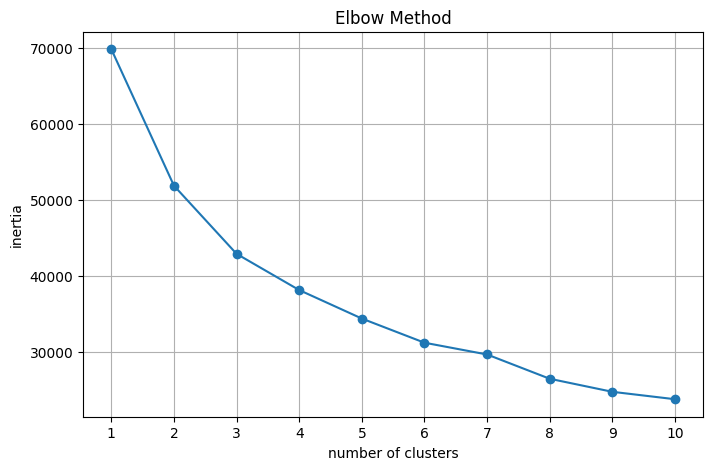

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ks = range(1, 11)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.title('Elbow Method')
plt.xticks(ks)
plt.grid(True)
plt.show()

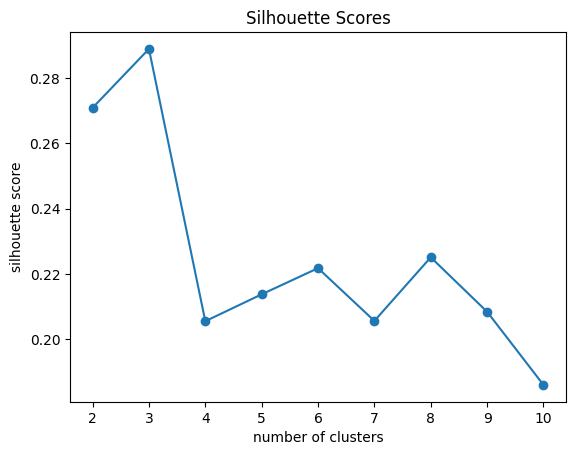

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel('number of clusters')
plt.ylabel('silhouette score')
plt.title('Silhouette Scores')
plt.show()

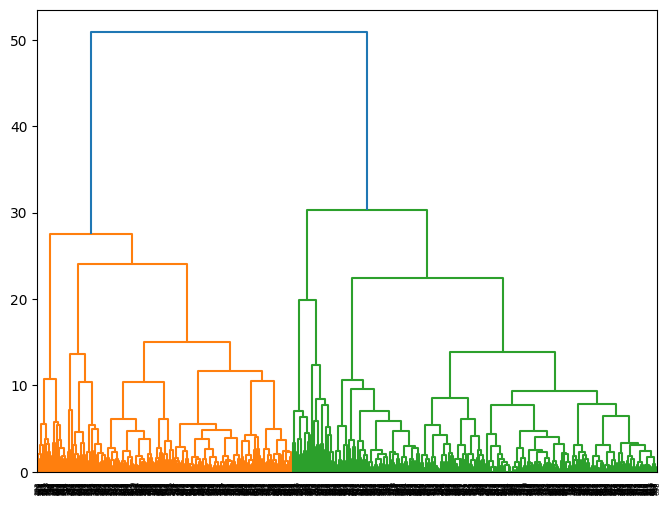

In [ ]:
from scipy.cluster import hierarchy

df_cluster1_sample = df_cluster1.sample(n = 1000, random_state = 100)

# create clusters using the "ward method"
clusters = hierarchy.linkage(df_cluster1_sample, method="ward")

# create the dendrogram using the hierarchy.dendrogram() method.
plt.figure(figsize=(8, 6))
dendrogram = hierarchy.dendrogram(clusters)


| Methods    | suggested K |
| ---------- | ----------- |
| Elbow      | ~5          |
| Silhouette | **3**       |
| Dendrogram | **2–4**     |


In [ ]:
# =====================
# K = 2
# =====================
df_k2 = df_cluster1.copy()
kmeans2 = KMeans(n_clusters=2, random_state=42)
df_k2["cluster"] = kmeans2.fit_predict(X)

summary_k2 = df_k2.groupby("cluster").mean()


# =====================
# K = 3
# =====================
df_k3 = df_cluster1.copy()
kmeans3 = KMeans(n_clusters=3, random_state=42)
df_k3["cluster"] = kmeans3.fit_predict(X)

summary_k3 = df_k3.groupby("cluster").mean()


# =====================
# K = 4
# =====================
df_k4 = df_cluster1.copy()
kmeans4 = KMeans(n_clusters=4, random_state=42)
df_k4["cluster"] = kmeans4.fit_predict(X)

summary_k4 = df_k4.groupby("cluster").mean()


# =====================
# K = 5
# =====================
df_k5 = df_cluster1.copy()
kmeans5 = KMeans(n_clusters=5, random_state=42)
df_k5["cluster"] = kmeans5.fit_predict(X)

summary_k5 = df_k5.groupby("cluster").mean()

In [ ]:
print("===== K = 2 =====")
print(summary_k2)

print("\n===== K = 3 =====")
print(summary_k3)

print("\n===== K = 4 =====")
print(summary_k4)

print("\n===== K = 5 =====")
print(summary_k5)

===== K = 2 =====
         RECENT_AVG_GIFT_AMT  RECENT_RESPONSE_PROP  RECENT_RESPONSE_COUNT  \
cluster                                                                     
0                  -0.432033              0.815653               0.964287   
1                   0.416160             -0.239340              -0.543150   

         MONTHS_SINCE_LAST_GIFT  LIFETIME_GIFT_AMOUNT  LAST_GIFT_AMT  
cluster                                                               
0                     -0.406068              0.435418      -0.471283  
1                      0.318725              0.155079       0.498944  

===== K = 3 =====
         RECENT_AVG_GIFT_AMT  RECENT_RESPONSE_PROP  RECENT_RESPONSE_COUNT  \
cluster                                                                     
0                  -0.494598              0.917914               1.102794   
1                   0.160655             -0.204645              -0.536119   
2                   1.507807             -0.118437            

In [ ]:
# Cluster distribution
print("\nCluster sizes (k=2):")
print(df_k2["cluster"].value_counts(normalize=True))

print("\nCluster sizes (k=3):")
print(df_k3["cluster"].value_counts(normalize=True))

print("\nCluster sizes (k=4):")
print(df_k4["cluster"].value_counts(normalize=True))

print("\nCluster sizes (k=5):")
print(df_k5["cluster"].value_counts(normalize=True))


Cluster sizes (k=2):
cluster
1    0.622714
0    0.377286
Name: proportion, dtype: float64

Cluster sizes (k=3):
cluster
1    0.578835
0    0.315560
2    0.105605
Name: proportion, dtype: float64

Cluster sizes (k=4):
cluster
1    0.422640
0    0.348378
3    0.139602
2    0.089381
Name: proportion, dtype: float64

Cluster sizes (k=5):
cluster
1    0.420575
0    0.331563
3    0.124410
4    0.079572
2    0.043879
Name: proportion, dtype: float64


## Final Selection of k

The clustering solutions for k = 2 to K = 5 were evaluated using both quantitative metrics and qualitative interpretation.

While k = 2 provides a coarse segmentation, it fails to capture meaningful behavioral differences. Increasing the number of clusters beyond k = 3 leads to over-segmentation, as observed in k = 4 and k = 5, where existing clusters are artificially split without introducing new, distinct behavioral patterns.

In particular, k = 5 produces very small clusters (below 5% of the population) and unstable segments driven by extreme values, indicating a loss of robustness.

The solution with k = 3 provides the best balance between:

* statistical quality (highest silhouette score),
* cluster stability (no excessively small groups),
* and interpretability (clear and distinct donor profiles).

Therefore, **k = 3 is selected as the optimal number of clusters** for the behavioral perspective.


In [ ]:
df_k3.groupby(['cluster']).describe().transpose()

cluster                                 0            1            2
RECENT_AVG_GIFT_AMT    count  4279.000000  7849.000000  1432.000000
                       mean     -0.494598     0.160655     1.507807
                       std       0.409072     0.569537     1.146653
                       min      -1.425000    -1.425000    -1.425000
                       25%      -0.798000    -0.175000     0.681750
                       50%      -0.542000     0.075000     1.242000
                       75%      -0.275000     0.575000     2.209750
                       max       3.169939     3.575000     3.575000
RECENT_RESPONSE_PROP   count  4279.000000  7849.000000  1432.000000
                       mean      0.917914    -0.204645    -0.118437
                       std       0.723988     0.464817     0.627461
                       min      -1.151724    -1.151724    -1.151724
                       25%       0.413793    -0.462069    -0.524138
                       50%       0.820690    -0.165517    -0.213793
                       75%       1.310345     0.000000     0.158621
                       max       2.682759     2.682759     2.682759
RECENT_RESPONSE_COUNT  count  4279.000000  7849.000000  1432.000000
                       mean      1.102794    -0.536119    -0.114469
                       std       0.935043     0.463638     0.828187
                       min      -1.500000    -1.500000    -1.500000
                       25%       0.500000    -1.000000    -0.500000
                       50%       1.000000    -0.500000    -0.500000
                       75%       1.500000     0.000000     0.500000
                       max       3.500000     1.500000     3.500000
MONTHS_SINCE_LAST_GIFT count  4279.000000  7849.000000  1432.000000
                       mean     -0.409688     0.328528    -0.147832
                       std       0.960893     0.883379     1.268536
                       min      -3.352500    -3.352500    -3.352500
                       25%      -0.750000    -0.250000    -0.500000
                       50%      -0.250000     0.000000     0.000000
                       75%       0.000000     0.750000     0.500000
                       max       2.000000     2.000000     2.000000
LIFETIME_GIFT_AMOUNT   count  4279.000000  7849.000000  1432.000000
                       mean      0.343796    -0.075053     1.854104
                       std       0.871805     0.566687     1.453318
                       min      -0.722222    -0.722222    -0.722222
                       25%      -0.266667    -0.555556     0.722222
                       50%       0.100000    -0.200000     1.522222
                       75%       0.688889     0.244444     2.900278
                       max       4.644444     2.922222     4.644444
LAST_GIFT_AMT          count  4279.000000  7849.000000  1432.000000
                       mean     -0.541056     0.218946     1.675050
                       std       0.466072     0.552235     1.278558
                       min      -1.300000    -1.300000    -1.300000
                       25%      -0.900000     0.000000     1.000000
                       50%      -0.500000     0.100000     1.400000
                       75%      -0.300000     0.500000     2.700000
                       max       3.754128     3.754128     3.754128

## Cluster Profiling (Behavioral Perspective – k = 3)

Based on the descriptive statistics of each cluster, three distinct donor profiles emerge, characterized by clear differences in engagement behavior and monetary contribution.

### Cluster 0 – Active Low-Value Donors (≈ 31.6%)

This segment is defined by **high engagement but low monetary contribution**.

* **High responsiveness**:

  * RECENT_RESPONSE_PROP (mean ≈ 0.92)
  * RECENT_RESPONSE_COUNT (mean ≈ 1.10)
* **Recent activity**:

  * MONTHS_SINCE_LAST_GIFT is below average (mean ≈ -0.41)
* **Low donation values**:

  * RECENT_AVG_GIFT_AMT (mean ≈ -0.49)
  * LAST_GIFT_AMT (mean ≈ -0.54)

These donors are highly responsive and actively engaged with campaigns, but their contributions remain relatively small. They represent a **loyal but low-value segment**, potentially suitable for upselling strategies.

---

### Cluster 1 – Low Engagement / Average Donors (≈ 57.9%)

This is the **largest segment**, characterized by relatively low engagement and average donation behavior.

* **Low responsiveness**:

  * RECENT_RESPONSE_PROP (mean ≈ -0.20)
  * RECENT_RESPONSE_COUNT (mean ≈ -0.54)
* **Less recent activity**:

  * MONTHS_SINCE_LAST_GIFT is above average (mean ≈ 0.33)
* **Moderate donation levels**:

  * RECENT_AVG_GIFT_AMT and LAST_GIFT_AMT slightly above average

This group represents a **less engaged and partially inactive segment**, with no strong behavioral signals. They may require reactivation strategies or more personalized communication to increase engagement.

---

### Cluster 2 – High-Value Donors (≈ 10.6%)

This segment includes donors with **significantly higher monetary contributions**, both recently and over their lifetime.

* **High donation amounts**:

  * RECENT_AVG_GIFT_AMT (mean ≈ 1.51)
  * LAST_GIFT_AMT (mean ≈ 1.68)
  * LIFETIME_GIFT_AMOUNT (mean ≈ 1.85)
* **Moderate engagement**:

  * RECENT_RESPONSE_PROP and RECENT_RESPONSE_COUNT around average
* **Relatively recent activity**:

  * MONTHS_SINCE_LAST_GIFT slightly below average

These donors are the **most valuable segment in terms of revenue**, although they are not the most responsive. They should be treated as priority individuals, with tailored retention and relationship-building strategies.

---

### Key Insight

The clustering reveals a clear **trade-off between engagement and monetary value**:

* Highly engaged donors tend to contribute smaller amounts
* High-value donors are less responsive but financially significant
* A large portion of the population remains weakly engaged

This segmentation provides a strong foundation for designing differentiated outreach strategies aligned with each donor profile.


In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

dists = euclidean_distances(kmeans3.cluster_centers_)
dists

array([[0.        , 2.38014235, 3.71781535],
       [2.38014235, 0.        , 2.84222908],
       [3.71781535, 2.84222908, 0.        ]])

## Distance Between Cluster Centroids

To further evaluate the separation between clusters, Euclidean distances between cluster centroids were computed.

The results show that the largest distance is observed between Cluster 0 and Cluster 2, indicating that these two groups represent the most distinct behavioral profiles. In particular, Cluster 0 is characterized by high engagement and low donation amounts, while Cluster 2 represents high-value donors.

Cluster 1 appears to occupy an intermediate position, as it shows moderate distances from both Cluster 0 and Cluster 2. This suggests that it acts as a transitional segment between low-value engaged donors and high-value contributors.

Overall, the centroid distances confirm that the clustering solution is well-structured, with clearly differentiated segments and meaningful behavioral separation.


In [ ]:
centroids_k3 = pd.DataFrame(kmeans3.cluster_centers_, columns=df_cluster1.columns)
centroids_k3

,RECENT_AVG_GIFT_AMT,RECENT_RESPONSE_PROP,RECENT_RESPONSE_COUNT,MONTHS_SINCE_LAST_GIFT,LIFETIME_GIFT_AMOUNT,LAST_GIFT_AMT
0,-0.492841,0.921295,1.096125,-0.410025,0.340521,-0.539366
1,0.161380,-0.208909,-0.535860,0.330350,-0.073779,0.219934
2,1.508716,-0.117605,-0.113309,-0.149542,1.856325,1.676117


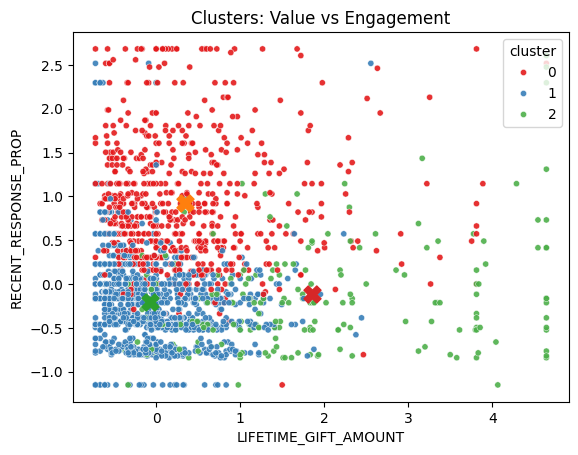

In [ ]:

x_col = "LIFETIME_GIFT_AMOUNT"
y_col = "RECENT_RESPONSE_PROP"

df_sample = df_k3.sample(2000, random_state=42)

sns.scatterplot(
    data=df_sample,
    x="LIFETIME_GIFT_AMOUNT",
    y="RECENT_RESPONSE_PROP",
    hue="cluster",
    palette="Set1",
    s=20,
    alpha=0.9
)
# Centroids
centroids = kmeans3.cluster_centers_
cols = df_k3.drop(columns="cluster").columns

cx = list(cols).index(x_col)
cy = list(cols).index(y_col)

for i in range(3):
    plt.scatter(
        centroids[i, cx],
        centroids[i, cy],
        marker='X',
        s=150
    )

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("Clusters: Value vs Engagement")
plt.show()

In [ ]:
# Import PCA
from sklearn.decomposition import PCA
import pandas as pd

# Select features only (exclude cluster column)
X_features = df_k3.drop(columns="cluster")

# Apply PCA with 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_features)

# Create PCA DataFrame
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = df_k3["cluster"].values

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


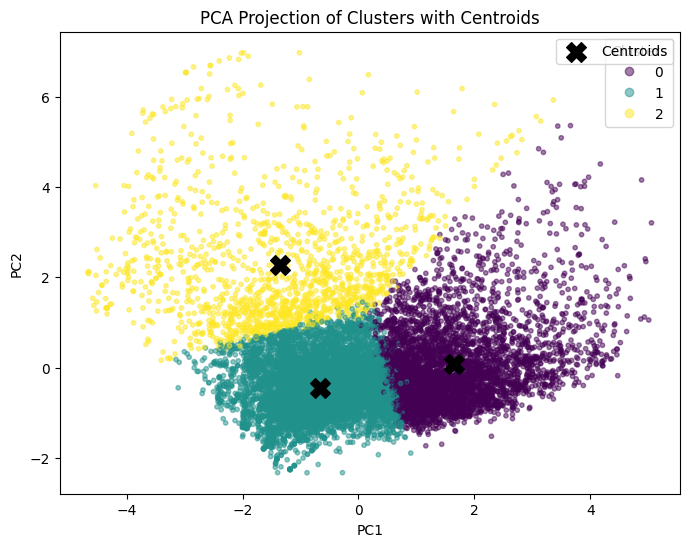

In [ ]:

# Create figure
plt.figure(figsize=(8,6))

# Scatter plot (points)
scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["cluster"],
    cmap="viridis",
    s=10,
    alpha=0.5
)

# Transform centroids into PCA space
centroids_pca = pca.transform(kmeans3.cluster_centers_)

# Plot centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    color='black',
    label='Centroids'
)

# Create legend for clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")

# Add centroid legend
plt.gca().add_artist(legend1)
plt.legend()

# Labels and title
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Clusters with Centroids")

# Show plot
plt.show()

In [ ]:
df_demog = df_clean[
    ["DONOR_GENDER", "SES", "URBANICITY", "INCOME_GROUP", "HOME_OWNER"]
].copy()

demo_view = pd.concat([df_k3, df_demog], axis=1)

In [ ]:
df_demog["cluster"] = df_k3["cluster"].values

In [ ]:
cluster0 = df_demog[df_demog["cluster"] == 0]
cluster1 = df_demog[df_demog["cluster"] == 1]
cluster2 = df_demog[df_demog["cluster"] == 2]

In [ ]:
# Example: gender distribution
(cluster0["DONOR_GENDER"].value_counts(normalize=True)*100).round(2)


,proportion
DONOR_GENDER,
F,55.71
M,38.51
U,5.77


In [ ]:
# Example: SES
(cluster1["SES"].value_counts(normalize=True)*100).round(2)

,proportion
SES,
2,50.12
1,31.33
3,16.59
4,1.96


In [ ]:
# Example: income
cluster2["INCOME_GROUP"].mean()

np.float64(4.138268156424581)

In [ ]:
# Flatten MultiIndex columns
cat_combined.columns = [
    f"{col[0]}_{col[1]}" for col in cat_combined.columns
]

# Now join works
full_summary = cat_combined.join(num_summary)

full_summary

,DONOR_GENDER_F,DONOR_GENDER_M,DONOR_GENDER_U,SES_1,SES_2,SES_3,SES_4,URBANICITY_C,URBANICITY_R,URBANICITY_S,URBANICITY_T,URBANICITY_U,HOME_OWNER_H,INCOME_GROUP
cluster,,,,,,,,,,,,,,
0,55.71,38.51,5.77,25.99,54.41,17.88,1.73,20.33,22.04,25.87,20.57,11.19,100.0,3.76
1,55.70,39.48,4.82,31.33,50.12,16.59,1.96,20.22,19.48,27.26,20.07,12.97,100.0,4.00
2,50.49,43.92,5.59,36.31,47.56,14.66,1.47,19.83,18.16,29.96,19.48,12.57,100.0,4.14


## Cluster Profiling - Behavioral Segmentation (Demographic Enrichment)

To complement the behavioral clustering, demographic and socio-economic variables were analyzed across the three clusters. The results reveal subtle but meaningful differences that help refine the interpretation of each segment.

### General Patterns

* Gender distribution is relatively consistent across all clusters, with a majority of female donors (about 55%) and a stable male representation ( about 38 - 44%).
* All individuals are homeowners, indicating a homogeneous characteristic across the dataset that does not contribute to cluster differentiation.
* The majority of donors across all clusters belong to SES levels 1 and 2, suggesting a concentration in lower to middle socio-economic segments.

---

### Cluster-Specific Insights

#### Cluster 0 — High Engagement, Lower Value

* Slightly higher concentration in SES level 2 (54.41%) with lower presence in SES level 1 (25.99%).
* More balanced urban distribution, with notable presence in suburban (S) and rural (R) areas.
* Lower average income (3.76), confirming that engagement is not necessarily driven by higher economic capacity.

👉 Interpretation:
This cluster consists of **highly engaged donors with moderate socio-economic profiles**, suggesting strong behavioral loyalty rather than financial strength.

---

#### Cluster 1 — Low Engagement, Mid Profile

* Similar SES distribution to Cluster 0, but slightly higher representation in SES level 1 (31.33%).
* Slightly higher presence in suburban areas.
* متوسط income level (4.00), indicating a middle-ground economic position.

👉 Interpretation:
This group represents **less engaged donors with average socio-economic characteristics**, potentially requiring reactivation strategies.

---

#### Cluster 2 — High Value Donors

* Highest proportion of individuals in SES level 1 (36.31%), indicating relatively stronger socio-economic positioning.
* Slightly higher male representation compared to other clusters.
* Highest average income (4.14), confirming economic capacity.
* More concentrated in suburban (S) areas.

👉 Interpretation:
This cluster includes **high-value donors with stronger economic profiles**, whose contribution is driven more by financial capability than engagement frequency.

---

### Key Takeaways

* Donation behavior is not solely determined by socio-economic status: highly engaged donors are not necessarily the wealthiest.
* High-value donors tend to exhibit better economic indicators but not necessarily higher engagement.
* The clusters reflect a clear distinction between **engagement-driven** and **value-driven** donor profiles.

Overall, integrating behavioral and demographic perspectives provides a more comprehensive segmentation, enabling more targeted and effective strategic decisions.


#Now we will proceed with the Socio-Economic perspective for the second clustering

In [ ]:
df_final.columns

Index(['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT',
       'FREQUENCY_STATUS_97NK', 'INCOME_GROUP', 'LAST_GIFT_AMT',
       'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_MIN_GIFT_AMT',
       'MEDIAN_HOME_VALUE', 'MONTHS_SINCE_LAST_GIFT',
       'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1',
       'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
       'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT',
       'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_PROP',
       'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS',
       'SES', 'URBANICITY', 'DONOR_GENDER_M', 'DONOR_GENDER_U'],
      dtype='object')

In [ ]:
features_demo = [
    "DONOR_AGE",
    "CHILDREN",
    "INCOME_GROUP",
    "MEDIAN_HOME_VALUE",
    "PCT_OWNER_OCCUPIED",
    "SES",
    "URBANICITY"
]

df_cluster2 = df_final[features_demo].copy()

In [ ]:
df_cluster2.describe()

,DONOR_AGE,CHILDREN,INCOME_GROUP,MEDIAN_HOME_VALUE,PCT_OWNER_OCCUPIED,SES,URBANICITY
count,13560.000000,13560.000000,13560.000000,13560.000000,13560.000000,13560.00000,13560.000000
mean,-0.046122,0.008260,-0.029388,0.470804,-0.248645,-0.09705,-0.043068
std,0.837563,0.713109,0.816664,1.383723,0.892932,0.73054,0.664457
min,-3.333333,-1.000000,-1.500000,-1.075714,-3.040000,-1.00000,-1.000000
25%,-0.500000,-0.500000,-0.500000,-0.330000,-0.640000,-1.00000,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,0.500000,0.500000,0.500000,0.670000,0.360000,0.00000,0.500000
max,2.718570,2.000000,1.500000,7.495714,2.353044,2.00000,1.000000


In [ ]:
# Apply quantile clipping to reduce extreme values
for col in df_cluster2.columns:
    lower = df_cluster2[col].quantile(0.01)
    upper = df_cluster2[col].quantile(0.99)
    df_cluster2[col] = df_cluster2[col].clip(lower, upper)

In [ ]:
df_cluster2.describe()

,DONOR_AGE,CHILDREN,INCOME_GROUP,MEDIAN_HOME_VALUE,PCT_OWNER_OCCUPIED,SES,URBANICITY
count,13560.000000,13560.000000,13560.000000,13560.000000,13560.000000,13560.00000,13560.000000
mean,-0.048004,0.003245,-0.029388,0.464116,-0.256053,-0.09705,-0.043068
std,0.805415,0.702521,0.816664,1.352638,0.877395,0.73054,0.664457
min,-2.411667,-1.000000,-1.500000,-1.075714,-3.040000,-1.00000,-1.000000
25%,-0.500000,-0.500000,-0.500000,-0.330000,-0.640000,-1.00000,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,0.500000,0.500000,0.500000,0.670000,0.360000,0.00000,0.500000
max,1.500000,1.000000,1.500000,6.427800,0.880000,2.00000,1.000000


## Outlier Treatment in Demographic Features

The descriptive analysis revealed the presence of moderate outliers, particularly in variables such as median home value and housing-related indicators. These extreme values could disproportionately influence the clustering results, leading to segments driven primarily by a single dimension.

To mitigate this issue, a quantile-based clipping approach was applied, limiting the values to the 1st and 99th percentiles. This ensures a more balanced representation of the data and allows the clustering algorithm to capture broader socio-demographic patterns rather than being dominated by extreme observations.


In [ ]:
df_cluster2["MEDIAN_HOME_VALUE"] = df_cluster2["MEDIAN_HOME_VALUE"].clip(
    df_cluster2["MEDIAN_HOME_VALUE"].quantile(0.01),
    df_cluster2["MEDIAN_HOME_VALUE"].quantile(0.99)
)

In [ ]:
df_cluster2.describe()


,DONOR_AGE,CHILDREN,INCOME_GROUP,MEDIAN_HOME_VALUE,PCT_OWNER_OCCUPIED,SES,URBANICITY
count,13560.000000,13560.000000,13560.000000,13560.000000,13560.000000,13560.00000,13560.000000
mean,-0.048004,0.003245,-0.029388,0.464095,-0.256053,-0.09705,-0.043068
std,0.805415,0.702521,0.816664,1.352546,0.877395,0.73054,0.664457
min,-2.411667,-1.000000,-1.500000,-1.075714,-3.040000,-1.00000,-1.000000
25%,-0.500000,-0.500000,-0.500000,-0.330000,-0.640000,-1.00000,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,0.500000,0.500000,0.500000,0.670000,0.360000,0.00000,0.500000
max,1.500000,1.000000,1.500000,6.425727,0.880000,2.00000,1.000000


In [ ]:
df_cluster2.std().sort_values(ascending=False)

,0
MEDIAN_HOME_VALUE,1.352546
PCT_OWNER_OCCUPIED,0.877395
INCOME_GROUP,0.816664
DONOR_AGE,0.805415
SES,0.730540
CHILDREN,0.702521
URBANICITY,0.664457


In [ ]:
df_cluster2.corr()["MEDIAN_HOME_VALUE"].sort_values(ascending=False)

,MEDIAN_HOME_VALUE
MEDIAN_HOME_VALUE,1.000000
URBANICITY,0.367858
INCOME_GROUP,0.250153
PCT_OWNER_OCCUPIED,0.033626
CHILDREN,0.010106
DONOR_AGE,-0.008367
SES,-0.440144


In [ ]:
kmeans_tmp = KMeans(n_clusters=3, random_state=42).fit(df_cluster2)
centroids_tmp = pd.DataFrame(kmeans_tmp.cluster_centers_, columns=df_cluster2.columns)
centroids_tmp

,DONOR_AGE,CHILDREN,INCOME_GROUP,MEDIAN_HOME_VALUE,PCT_OWNER_OCCUPIED,SES,URBANICITY
0,0.192949,0.000581,-0.574473,-0.185678,-0.595906,0.356444,-0.177558
1,-0.012239,0.026247,0.379593,3.637102,-0.338619,-0.739501,0.491470
2,-0.298913,0.000083,0.413934,0.311242,0.105991,-0.389213,-0.043699


In [ ]:
import numpy as np

col = "MEDIAN_HOME_VALUE"

shift = abs(df_cluster2[col].min()) + 1
df_cluster2[col] = np.log1p(df_cluster2[col] + shift)

In [ ]:
# Basic stats
print(df_cluster2.describe())

# Std ranking (to verify balance)
print("\nStd by feature:")
print(df_cluster2.std().sort_values(ascending=False))

          DONOR_AGE      CHILDREN  INCOME_GROUP  MEDIAN_HOME_VALUE  \
count  13560.000000  13560.000000  13560.000000       13560.000000   
mean      -0.048004      0.003245     -0.029388           1.211215   
std        0.805415      0.702521      0.816664           0.302928   
min       -2.411667     -1.000000     -1.500000           0.693147   
25%       -0.500000     -0.500000     -0.500000           1.010041   
50%        0.000000      0.000000      0.000000           1.123537   
75%        0.500000      0.500000      0.500000           1.320612   
max        1.500000      1.000000      1.500000           2.251443   

       PCT_OWNER_OCCUPIED          SES    URBANICITY  
count        13560.000000  13560.00000  13560.000000  
mean            -0.256053     -0.09705     -0.043068  
std              0.877395      0.73054      0.664457  
min             -3.040000     -1.00000     -1.000000  
25%             -0.640000     -1.00000     -0.500000  
50%              0.000000      0.00000 

In [ ]:
corr = df_cluster2.corr()
print(corr["MEDIAN_HOME_VALUE"].sort_values(ascending=False))

MEDIAN_HOME_VALUE     1.000000
URBANICITY            0.400077
INCOME_GROUP          0.275585
PCT_OWNER_OCCUPIED    0.057161
CHILDREN              0.009590
DONOR_AGE            -0.014388
SES                  -0.492029
Name: MEDIAN_HOME_VALUE, dtype: float64


## Feature Transformation Validation

The application of a logarithmic transformation to the MEDIAN_HOME_VALUE variable successfully reduced its variance and mitigated its dominant effect in the clustering process.

Post-transformation analysis shows that all variables now exhibit a balanced scale, with no single feature disproportionately influencing the results. Additionally, the correlation structure confirms that the variable retains its informational value without introducing redundancy.

This ensures that the clustering algorithm captures a multidimensional socio-demographic structure, rather than being driven primarily by wealth-related characteristics.


In [ ]:
X = df_cluster2.values

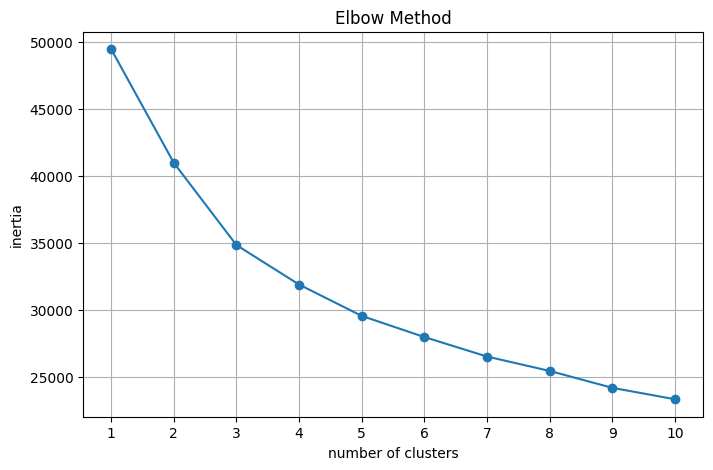

In [ ]:
ks = range(1, 11)
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.title('Elbow Method')
plt.xticks(ks)
plt.grid(True)
plt.show()

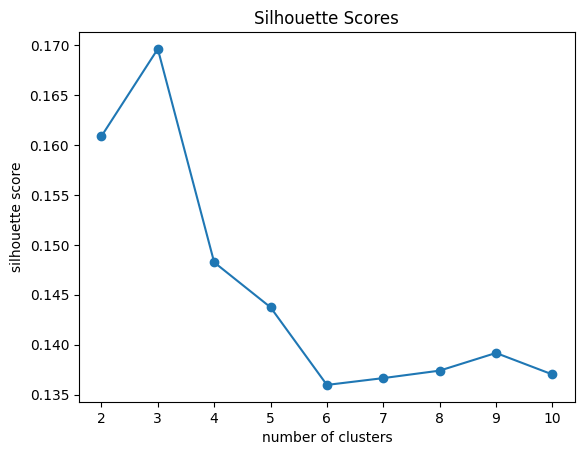

In [ ]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.plot(range(2,11), sil_scores, marker='o')
plt.xlabel('number of clusters')
plt.ylabel('silhouette score')
plt.title('Silhouette Scores')
plt.show()

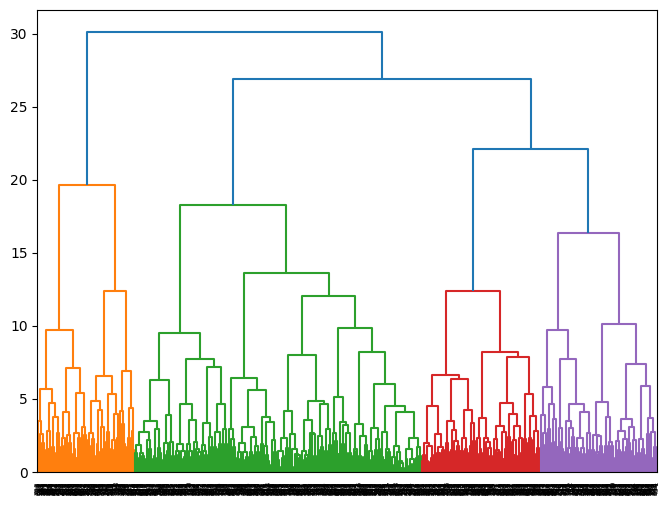

In [ ]:
df_cluster2_sample = df_cluster2.sample(n = 1000, random_state = 100)

# create clusters using the "ward method"
clusters = hierarchy.linkage(df_cluster2_sample, method="ward")

# create the dendrogram using the hierarchy.dendrogram() method.
plt.figure(figsize=(8, 6))
dendrogram = hierarchy.dendrogram(clusters)

## Selection of the Optimal Number of Clusters

The optimal number of clusters was determined using a combination of the Elbow Method, Silhouette Analysis, and hierarchical clustering (dendrogram).

The Elbow Method suggests a clear inflection point at k = 3, where the reduction in inertia begins to diminish significantly. This is further supported by the Silhouette Score, which reaches its maximum value at k = 3, indicating the best balance between cluster cohesion and separation.

Additionally, the dendrogram reveals a natural grouping structure consistent with three main clusters, with subsequent splits appearing less significant.

Although the silhouette values are moderate, this is expected given the nature of demographic data, which tends to exhibit gradual transitions rather than sharply defined segments.

Overall, k = 3 was selected as the optimal number of clusters, providing a robust and interpretable segmentation of the dataset.


In [ ]:
df_k3 = df_cluster2.copy()
kmeans3 = KMeans(n_clusters=3, random_state=42)
df_k3["cluster"] = kmeans3.fit_predict(X)

summary_k3 = df_k3.groupby("cluster").mean()
summary_k3


,DONOR_AGE,CHILDREN,INCOME_GROUP,MEDIAN_HOME_VALUE,PCT_OWNER_OCCUPIED,SES,URBANICITY
cluster,,,,,,,
0,0.211704,0.011196,-0.528582,1.069900,0.003918,0.245767,-0.431276
1,-0.311060,0.000000,0.560310,1.341342,0.184087,-0.550904,0.136850
2,-0.048111,-0.006616,-0.201512,1.237942,-1.698194,0.121361,0.394329


In [ ]:
print("\nCluster sizes (k=3):")
df_k3["cluster"].value_counts(normalize=True)


Cluster sizes (k=3):


,proportion
cluster,
0,0.405088
1,0.399853
2,0.195059


In [ ]:
df_k3.groupby(['cluster']).describe().transpose()

cluster                             0            1            2
DONOR_AGE          count  5493.000000  5422.000000  2645.000000
                   mean      0.211704    -0.311060    -0.048111
                   std       0.700911     0.814252     0.815347
                   min      -2.411667    -2.411667    -2.411667
                   25%       0.000000    -0.833333    -0.500000
                   50%       0.000000    -0.111111     0.000000
                   75%       0.722222     0.055556     0.500000
                   max       1.500000     1.500000     1.500000
CHILDREN           count  5493.000000  5422.000000  2645.000000
                   mean      0.011196     0.000000    -0.006616
                   std       0.702270     0.702067     0.704061
                   min      -1.000000    -1.000000    -1.000000
                   25%      -0.500000    -0.500000    -0.500000
                   50%       0.000000     0.000000     0.000000
                   75%       0.500000     0.500000     0.500000
                   max       1.000000     1.000000     1.000000
INCOME_GROUP       count  5493.000000  5422.000000  2645.000000
                   mean     -0.528582     0.560310    -0.201512
                   std       0.641277     0.606303     0.742867
                   min      -1.500000    -1.500000    -1.500000
                   25%      -1.000000     0.000000    -1.000000
                   50%      -0.500000     0.500000     0.000000
                   75%       0.000000     1.000000     0.000000
                   max       1.500000     1.500000     1.500000
MEDIAN_HOME_VALUE  count  5493.000000  5422.000000  2645.000000
                   mean      1.069900     1.341342     1.237942
                   std       0.182270     0.321313     0.336127
                   min       0.693147     0.693147     0.693147
                   25%       0.957158     1.112327     1.026042
                   50%       1.034201     1.242094     1.151476
                   75%       1.123537     1.501534     1.413423
                   max       2.251443     2.251443     2.251443
PCT_OWNER_OCCUPIED count  5493.000000  5422.000000  2645.000000
                   mean      0.003918     0.184087    -1.698194
                   std       0.424656     0.481210     0.692985
                   min      -1.520000    -1.800000    -3.040000
                   25%      -0.280000    -0.120000    -2.200000
                   50%       0.040000     0.280000    -1.560000
                   75%       0.320000     0.560000    -1.160000
                   max       0.880000     0.880000    -0.200000
SES                count  5493.000000  5422.000000  2645.000000
                   mean      0.245767    -0.550904     0.121361
                   std       0.564521     0.551273     0.858799
                   min      -1.000000    -1.000000    -1.000000
                   25%       0.000000    -1.000000     0.000000
                   50%       0.000000    -1.000000     0.000000
                   75%       1.000000     0.000000     1.000000
                   max       2.000000     2.000000     2.000000
URBANICITY         count  5493.000000  5422.000000  2645.000000
                   mean     -0.431276     0.136850     0.394329
                   std       0.589466     0.578859     0.533384
                   min      -1.000000    -1.000000    -1.000000
                   25%      -1.000000    -0.500000     0.000000
                   50%      -0.500000     0.500000     0.500000
                   75%       0.000000     0.500000     1.000000
                   max       1.000000     1.000000     1.000000

## Demographic Cluster Interpretation

The demographic clustering reveals three distinct socio-economic profiles, driven primarily by income, housing characteristics, and geographic context.

Cluster 0 represents older individuals with lower income levels, typically residing in less urbanized areas. Despite their lower economic status, they exhibit relatively stable housing conditions.

Cluster 1 consists of younger and more affluent individuals, characterized by higher income levels, greater home ownership, and a stronger presence in urban environments.

Cluster 2 represents a more vulnerable segment, defined by significantly lower levels of home ownership. Although not the lowest in income, this group appears to experience reduced housing stability and is more concentrated in urban areas.

Overall, the segmentation highlights that housing conditions and geographic factors play a crucial role alongside income in defining socio-demographic profiles.


In [ ]:
dists = euclidean_distances(kmeans3.cluster_centers_)
dists

array([[0.        , 1.58810826, 1.94981635],
       [1.58810826, 0.        , 2.17166174],
       [1.94981635, 2.17166174, 0.        ]])

In [ ]:
centroids_k3 = pd.DataFrame(kmeans3.cluster_centers_, columns=df_cluster2.columns)
centroids_k3

,DONOR_AGE,CHILDREN,INCOME_GROUP,MEDIAN_HOME_VALUE,PCT_OWNER_OCCUPIED,SES,URBANICITY
0,0.213821,0.012694,-0.531142,1.069797,0.003996,0.246027,-0.431233
1,-0.311424,-0.001562,0.559180,1.340514,0.183275,-0.548429,0.134994
2,-0.048087,-0.006430,-0.201589,1.237970,-1.698625,0.121407,0.394289


## Cluster Separation Analysis

The Euclidean distance between cluster centroids reveals a clear structure in the segmentation. The largest distance is observed between Cluster 1 and Cluster 2, indicating that these groups are the most dissimilar.

Cluster 2 stands out as a distinct segment primarily characterized by significantly lower levels of home ownership, suggesting reduced housing stability. In contrast, Clusters 0 and 1 appear closer to each other and represent more stable populations, differentiated mainly by income and socio-economic status.

This suggests a two-level segmentation structure: first, a separation based on housing stability, and second, a division based on economic conditions. Such a structure highlights the importance of non-income variables, particularly housing-related indicators, in defining meaningful demographic segments.


In [ ]:
print(df_cluster2.columns)

Index(['DONOR_AGE', 'CHILDREN', 'INCOME_GROUP', 'MEDIAN_HOME_VALUE',
       'PCT_OWNER_OCCUPIED', 'SES', 'URBANICITY', 'cluster'],
      dtype='object')


In [ ]:
print(df_cluster2["cluster"].isna().sum())
print(df_cluster2["cluster"].unique())

0
[1 0 2]


In [ ]:
df_cluster2["cluster"] = kmeans_demo.labels_.astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


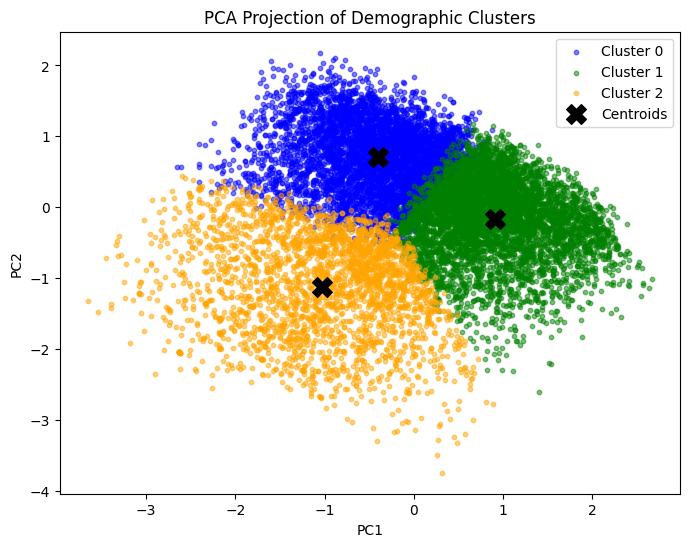

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features
X = df_cluster2.drop(columns="cluster")

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Dataframe PCA
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = df_cluster2["cluster"].values

# Plot
plt.figure(figsize=(8,6))

colors = {0: "blue", 1: "green", 2: "orange"}

for c in [0, 1, 2]:  # <-- evita NaN direttamente
    subset = df_pca[df_pca["cluster"] == c]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=10,
        alpha=0.5,
        label=f"Cluster {c}",
        color=colors[c]
    )

# Centroids
centroids_pca = pca.transform(kmeans_demo.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=200,
    color='black',
    label='Centroids'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Demographic Clusters")

plt.legend()
plt.show()

The PCA projection confirms the existence of three distinct demographic segments:

- Cluster 1 represents high-income, urban donors, clearly separated along the first principal component.
- Cluster 2 captures economically vulnerable donors, strongly differentiated along the second component, driven by housing instability.
- Cluster 0 lies between these extremes, representing a more stable and moderate socio-economic group.

Although some overlap exists, the clusters exhibit clear structural separation, supporting the validity of the segmentation.

In [ ]:
# Rename clusters for clarity
df_cluster1 = df_cluster1.rename(columns={"cluster": "behavior_cluster"})
df_cluster2 = df_cluster2.rename(columns={"cluster": "demo_cluster"})

In [ ]:
# Merge on index
df_cross = df_cluster1.join(df_cluster2["demo_cluster"])

In [ ]:
df_cross

,RECENT_AVG_GIFT_AMT,RECENT_RESPONSE_PROP,RECENT_RESPONSE_COUNT,MONTHS_SINCE_LAST_GIFT,LIFETIME_GIFT_AMOUNT,LAST_GIFT_AMT,behavior_cluster,demo_cluster
CONTROL_NUMBER,,,,,,,,
61745,0.325,-0.089655,-0.5,0.00,-0.500000,0.5,1,1
112703,0.075,-0.462069,-1.0,1.50,-0.722222,0.0,1,0
166437,-0.358,0.441379,0.0,-0.75,-0.011111,-0.5,0,1
170621,-0.425,-0.386207,-0.5,-0.50,0.000000,-0.4,1,1
44428,-0.885,2.296552,1.0,-0.25,-0.588889,-0.8,0,0
...,...,...,...,...,...,...,...,...
34797,-0.425,0.000000,-0.5,0.25,0.611111,-0.5,1,1
7550,-0.675,0.303448,0.5,-0.25,1.166667,-0.5,0,2
115215,-0.525,0.468966,0.0,-0.25,-0.433333,-0.5,0,2


In [ ]:
cross_tab = pd.crosstab(
    df_cross["behavior_cluster"],
    df_cross["demo_cluster"],
    normalize="index"
).round(3)

cross_tab

demo_cluster,0,1,2
behavior_cluster,,,
0,0.465,0.348,0.186
1,0.382,0.417,0.201
2,0.351,0.458,0.191


The cross-analysis between behavioral and demographic clusters shows no strong one-to-one correspondence between the two segmentations.

Each behavioral cluster is composed of a mix of demographic profiles, indicating that donor behavior is not solely driven by socio-economic characteristics.

This suggests that individuals with similar economic backgrounds can exhibit different donation behaviors, and conversely, donors with diverse demographic profiles may behave similarly.

The two clustering perspectives are therefore complementary and provide a richer segmentation when combined.